In [54]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
from matplotlib.patches import Ellipse

In [2]:
np.random.seed(33550336)

In [3]:
mu0 = 0
sigma20= 4
sigma2 = 1
n = 10
xb = 2.5
sigma2n = 1 / (1 / sigma20 + n/sigma2)
mun = sigma2n * (mu0 / sigma20 + n *xb/sigma2)

In [4]:
x = np.linspace(-4, 5, 500)

In [5]:
from scipy.stats import norm

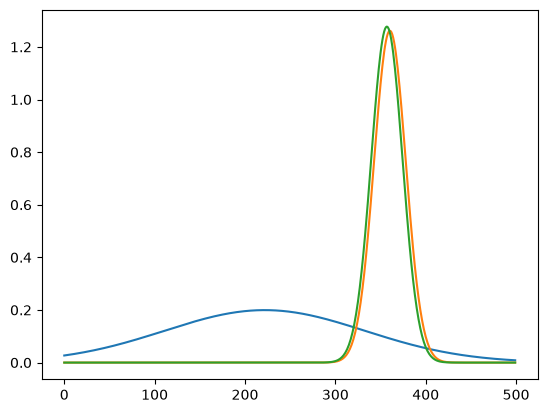

In [6]:
plt.plot(norm.pdf(x, loc = 0, scale = 2))
plt.plot(norm.pdf(x, loc = 2.5, scale = np.sqrt(1/10)))
plt.plot(norm.pdf(x, loc = mun, scale = np.sqrt(sigma2n)))

In [7]:
pit = np.array([0.4, 0.6])
mut = np.array([-2.0, 3.0])
sigt = np.array([1.0, 0.5])

In [8]:
pg = np.array([0.5, 0.5])
mg = np.array([0.0, 1.0])
sg = np.array([1.0, 1.0])

In [9]:
comp = np.random.choice([0, 1], size = 1000, p = pit)
x = np.random.normal(loc = mut[comp], scale = sigt[comp])

In [10]:
for _ in range(100):
    omg = mg
    l0 = sp.stats.norm.pdf(x, loc = mg[0], scale = sg[0])
    l1 = sp.stats.norm.pdf(x, loc = mg[1], scale = sg[1])
    w0 = pg[0] * l0
    w1 = pg[1] * l1
    r0 = w0 / (w0 + w1)
    r1 = w1 / (w0 + w1)
    mu1 = np.sum(r0 * x) / np.sum(r0)
    mu2 = np.sum(r1 * x) / np.sum(r1)
    s1 = np.sqrt(np.sum( r0 * (x - mu1) ** 2) / np.sum(r0))
    s2 = np.sqrt(np.sum(r1 * (x - mu2) ** 2) / np.sum(r1))
    pi1= np.sum(r0) / 1000
    pi2 = np.sum(r1) / 1000
    mg = [mu1, mu2]
    sg = [s1, s2]
    pg = [pi1, pi2]

In [11]:
mu1

np.float64(-1.9476229862138963)

In [12]:
mu2

np.float64(2.9676391540029976)

In [13]:
s1

np.float64(1.0151447264890392)

In [14]:
s2

np.float64(0.5134518203206976)

In [15]:
pi1

np.float64(0.3912858049210351)

In [16]:
pi2

np.float64(0.6087141950789648)

In [33]:
sig0 = np.array([[1, 0], [0, 1]])
mu0 = np.array([-2, 1])
mu1 = np.array([3, -1])
sig1 = np.array([[0.5, 0.3], [0.3, 0.5]])
mut = [mu0, mu1]
sigt = [sig0, sig1]

In [27]:
N = 1000
comp = np.random.choice([0, 1], size = N, p = pit)

In [36]:
X = np.array([np.random.multivariate_normal(mut[c], sigt[c]) for c in comp])
idx = np.random.choice(1000, size=2, replace=False)
mg = X[idx] 
sg = np.array([np.eye(2), np.eye(2)])
pg = np.array([0.5, 0.5])

In [37]:
for _ in range(100):
    l0 = sp.stats.multivariate_normal.pdf(X, mean = mg[0], cov = sg[0])
    l1 = sp.stats.multivariate_normal.pdf(X, mean = mg[1], cov = sg[1])
    w0 = pg[0] * l0
    w1 = pg[1] * l1
    r0 = w0 / (w0 + w1)
    r1 = w1 / (w0 + w1)
    mu0 = (r0[:, None] * X).sum(axis = 0) / r0.sum()
    mu1 = (r1[:, None] * X).sum(axis = 0) / r1.sum()
    diff0 = X - mu0
    diff1 = X - mu1
    o0 = diff0[:, :, None] * diff0[:, None, :]
    s0 = (r0[:, None, None] * o0).sum(axis = 0) / r0.sum()
    o1 = diff1[:, :, None] * diff1[:, None, :]
    s1 = (r1[:, None, None] * o1).sum(axis = 0) / r1.sum()
    s0 += 1e-6 * np.eye(2)
    s1 += 1e-6 * np.eye(2)
    p0 = np.sum(r0) / 1000
    p1 = np.sum(r1) / 1000
    mg = np.array([mu0, mu1])
    sg = np.array([s0, s1])
    pg = np.array([p0, p1])

In [38]:
mu0

array([-2.01246936,  0.95088258])

In [39]:
mu1

array([ 3.01383903, -1.00565039])

In [40]:
p0

np.float64(0.4093782296752656)

In [41]:
p1

np.float64(0.5906217703247345)

In [42]:
s0

array([[ 1.05618729, -0.0115712 ],
       [-0.0115712 ,  0.9649001 ]])

In [43]:
s1

array([[0.50781958, 0.28807508],
       [0.28807508, 0.50592369]])

In [46]:
eig0, eiv0 = np.linalg.eig(s0)
eig1, eiv1 = np.linalg.eig(s1)

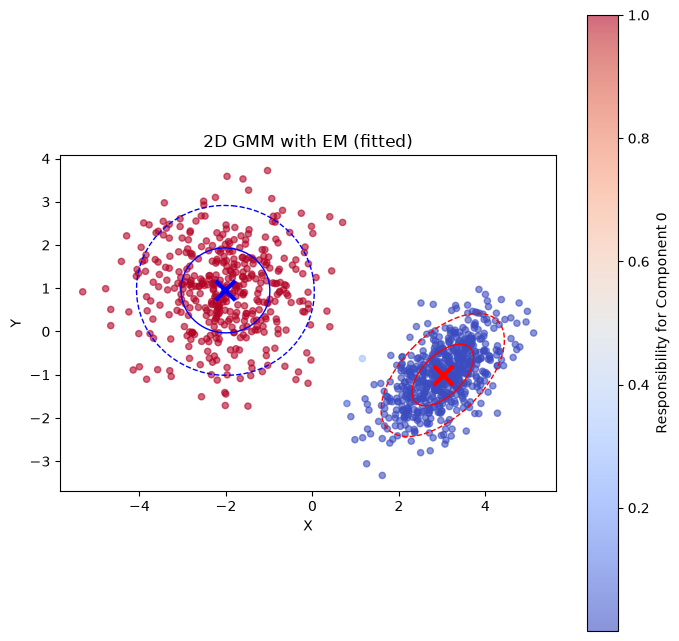

In [63]:
fig, ax = plt.subplots(figsize = (8, 8))
colors = r0 
scatter = ax.scatter(X[:, 0], X[:, 1], c = colors, cmap = 'coolwarm', alpha = 0.6, s = 20)

def de(ax, mu, s, col, nstd = 1.0, **kwargs):
    eig, eiv = np.linalg.eigh(s)
    ord = eig.argsort()[::-1]
    eig = eig[ord]
    eiv = eiv[:, ord]
    eigc = np.maximum(eig, 0)
    ang = np.degrees(np.arctan2(eiv[1, 0], eiv[0, 0]))
    w, h = 2 * nstd * np.sqrt(eig)
    elp = Ellipse(xy = mu, width = w, height = h, angle = ang, edgecolor = col, facecolor = 'none', **kwargs)
    ax.add_patch(elp)

de(ax, mu0, s0, 'blue', nstd = 1.0)
de(ax, mu0, s0, 'blue', nstd = 2.0, linestyle = '--', linewidth = 1)
de(ax, mu1, s1, 'red', nstd = 1.0)
de(ax, mu1, s1, 'red', nstd = 2.0, linestyle = '--', linewidth = 1)
ax.scatter(*mu0, c = 'blue', marker = 'x', s = 200, linewidths = 3)
ax.scatter(*mu1, c = 'red', marker = 'x', s = 200, linewidth = 3)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('2D GMM with EM (fitted)')
ax.set_aspect('equal')
plt.colorbar(scatter, label = 'Responsibility for Component 0')
plt.show()